In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**bib **

In [ ]:
import os
import cv2
import numpy as np
import random
import logging
import shutil
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

creation de metadonnee

In [ ]:


#fixer le seed pour avoir les meme images lors de la regeneration de code
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

#logger au cas d erreur
LOG_DIR = "/content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/train/logs"
os.makedirs(LOG_DIR, exist_ok=True)
logging.basicConfig(
    filename=os.path.join(LOG_DIR, "kaggle_preprocessing.log"),
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    filemode="w"
)

def log_issue(img_file, message):
    logging.warning(f"{img_file} - {message}")
    print("!!!", img_file, "-", message)

#path pour dataset /fixer nb des images selectionner =3000
dataset_dir = "content//drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8"
splits = ["train"]
MAX_IMAGES_TRAIN = 3000  # nombre max d'images à sélectionner


# DOSSIERS DE SAUVEGARDE pour les outputs
SAVE_DIR = os.path.join(dataset_dir, "selected_data")
SAVE_IMAGES_DIR = os.path.join(SAVE_DIR, "selected_images")
SAVE_MASKS_DIR = os.path.join(SAVE_DIR, "selected_masks")
os.makedirs(SAVE_IMAGES_DIR, exist_ok=True)
os.makedirs(SAVE_MASKS_DIR, exist_ok=True)
# FONCTION HARMONISATION
def harmonize_mask(mask):
    return np.where(mask > 127, 255, 0).astype(np.uint8)
# TRAITEMENT DES IMAGES
for split in splits:
    images_folder = os.path.join(dataset_dir, split, "images")
    labels_folder = os.path.join(dataset_dir, split, "labels")
    masks_folder = os.path.join(dataset_dir, split, "masks2")
    os.makedirs(masks_folder, exist_ok=True)

    # Lister les images ayant un label
    all_images = [
        f for f in os.listdir(images_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
        and os.path.exists(os.path.join(labels_folder, f.replace(".png", ".txt").replace(".jpg", ".txt")))
    ]

    # Limiter à MAX_IMAGES_TRAIN
    if len(all_images) > MAX_IMAGES_TRAIN:
        selected_images = random.sample(all_images, MAX_IMAGES_TRAIN)
    else:
        selected_images = all_images

    print(f"[{split}] Nombre d'images sélectionnées avec label : {len(selected_images)}")

    saved_count = 0

    for img_file in selected_images:
        img_path = os.path.join(images_folder, img_file)
        img = cv2.imread(img_path)
        if img is None:
            log_issue(img_file, "Impossible de lire l'image")
            continue

        height, width = img.shape[:2]
        mask = np.zeros((height, width), dtype=np.uint8)

        label_file = os.path.join(labels_folder, img_file.replace(".png", ".txt").replace(".jpg", ".txt"))
        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            cls = int(parts[0])

            # bbox rectangle YOLO format
            if len(parts) == 5:
                x_center, y_center, w, h = map(float, parts[1:])
                x_center *= width
                y_center *= height
                w *= width
                h *= height
                x_min = max(0, int(x_center - w / 2))
                y_min = max(0, int(y_center - h / 2))
                x_max = min(width - 1, int(x_center + w / 2))
                y_max = min(height - 1, int(y_center + h / 2))
                cv2.rectangle(mask, (x_min, y_min), (x_max, y_max), 255, -1)

            # polygone (si plus de 5 valeurs)
            elif len(parts) > 5:
                coords = list(map(float, parts[1:]))
                pts = [[int(coords[i]*width), int(coords[i+1]*height)] for i in range(0, len(coords), 2)]
                pts = [[max(0, min(width-1, x)), max(0, min(height-1, y))] for x, y in pts]
                pts = np.array(pts, dtype=np.int32)
                cv2.fillPoly(mask, [pts], 255)

        # Harmoniser le masque
        mask = harmonize_mask(mask)

        # Vérifications
        if mask.sum() == 0:
            log_issue(img_file, "Masque vide, image ignorée")
            continue

        if mask.shape[:2] != img.shape[:2]:
            log_issue(img_file, f"Taille masque {mask.shape[:2]} != taille image {img.shape[:2]}")
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Sauvegarde du masque
        base_name, _ = os.path.splitext(img_file)
        mask_path = os.path.join(masks_folder, f"{base_name}_mask.png")
        cv2.imwrite(mask_path, mask)

        # Vérification existence
        if not os.path.exists(mask_path):
            log_issue(mask_path, "Masque introuvable après sauvegarde")
            continue

        # Copie dans les dossiers finaux
        shutil.copy2(img_path, os.path.join(SAVE_IMAGES_DIR, img_file))
        shutil.copy2(mask_path, os.path.join(SAVE_MASKS_DIR, f"{base_name}_mask.png"))

        saved_count += 1

    print(f" {saved_count} images et masques sauvegardés depuis '{split}'")

print("\n Prétraitement terminé :")
print(f"- Dossier images sélectionnées : {SAVE_IMAGES_DIR}")
print(f"- Dossier masques sélectionnés : {SAVE_MASKS_DIR}")
#====================================================================================  CRÉATION DES MÉTADONNÉES====================================================================
selected_dir = SAVE_DIR  # on utilise le même dossier de sortie
# Définition des classes
class_names = [
    'elbow positive', 'fingers positive', 'forearm fracture',
    'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive'
]
metadata_path = os.path.join(selected_dir, "metadata.csv")
log_file = os.path.join(selected_dir, "metadata_generation.log")
logging.basicConfig(filename=log_file, level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

print("\n Création du fichier de métadonnées...")

with open(metadata_path, mode="w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["image_name", "class_id", "class_name", "x_values", "y_values"])

    for split in splits:
        images_folder = os.path.join(dataset_dir, split, "images")
        labels_folder = os.path.join(dataset_dir, split, "labels")
        masks_folder = os.path.join(dataset_dir, split, "masks2")

        for mask_file in os.listdir(masks_folder):
            if not mask_file.endswith("_mask.png"):
                continue

            img_name = mask_file.replace("_mask.png", ".jpg")
            if not os.path.exists(os.path.join(images_folder, img_name)):
                img_name = mask_file.replace("_mask.png", ".png")

            label_path = os.path.join(labels_folder, img_name.replace(".jpg", ".txt").replace(".png", ".txt"))
            if not os.path.exists(label_path):
                log_issue(img_name, "Label introuvable pour métadonnées")
                continue

            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 3:
                        continue

                    class_id = int(parts[0])
                    if class_id >= len(class_names):
                        log_issue(img_name, f"Classe inconnue ({class_id})")
                        continue

                    coords = list(map(float, parts[1:]))
                    x_values = coords[0::2]
                    y_values = coords[1::2]

                    writer.writerow([
                        img_name,
                        class_id,
                        class_names[class_id],
                        " ".join(map(str, x_values)),
                        " ".join(map(str, y_values))
                    ])

print(f"\n Copie et métadonnées terminées dans : {selected_dir}")
print(f" Fichier CSV : {metadata_path}")
print(f" Log : {log_file}")


[train] Nombre d'images sélectionnées avec label : 3000
⚠️ image1_272_png.rf.f0bde1ea9d8de47597ec599fcc959930.jpg - Masque vide, image ignorée
⚠️ image1_873_png.rf.ddef7860f6beab9606c0328050b4f416.jpg - Masque vide, image ignorée
⚠️ image1_62_png.rf.a4dd42438ef86aeab17cf5114a3077eb.jpg - Masque vide, image ignorée
⚠️ image1_1067_png.rf.0c1bc59eb683d807e5931f8f151ed366.jpg - Masque vide, image ignorée
⚠️ image1_349_png.rf.965f5bfec335ade59a123a34d69fdbc2.jpg - Masque vide, image ignorée
⚠️ image1_340_png.rf.f51c3e3d718ae31e6c887bda4d575a95.jpg - Masque vide, image ignorée


⚠️ image1_1014_png.rf.89f2f751efb9b40886e161726ce97513.jpg - Masque vide, image ignorée
⚠️ image1_937_png.rf.dd1ed892d04ed465555640715c21fc18.jpg - Masque vide, image ignorée
⚠️ image1_166_png.rf.797d6811683861bb94721e75c5fe556d.jpg - Masque vide, image ignorée


⚠️ image1_239_png.rf.910399b52144d90934261a5aa28284dc.jpg - Masque vide, image ignorée
⚠️ image1_468_png.rf.8187fcd547d76bc135f5a646ed701e2f.jpg - Masque vide, image ignorée
⚠️ image1_640_png.rf.5a84b40f96b933c345b40312cb267a56.jpg - Masque vide, image ignorée
⚠️ image1_863_png.rf.5d5faa81b374acca10c48a211e2ed736.jpg - Masque vide, image ignorée


⚠️ image1_191_png.rf.4281c0740362e3f7870d931d1e405aab.jpg - Masque vide, image ignorée
⚠️ image1_203_png.rf.47f8a8ada503ad61a8be72ba83899be0.jpg - Masque vide, image ignorée


⚠️ image1_284_png.rf.899bfdc84639ac8001f5e38be37bfb4b.jpg - Masque vide, image ignorée
⚠️ image1_297_png.rf.019b724b4d58aa4f6cbb809198d34a38.jpg - Masque vide, image ignorée
⚠️ image1_187_png.rf.5441e4129572c85651d95a2ef8143ba8.jpg - Masque vide, image ignorée
⚠️ image1_487_png.rf.64f768c029307710a838a2b666f54fc3.jpg - Masque vide, image ignorée
⚠️ image1_515_png.rf.53767dc769f5f9891bccdf2289929925.jpg - Masque vide, image ignorée
⚠️ image1_240_png.rf.d72dcd022fb417d297482e19ade94169.jpg - Masque vide, image ignorée
⚠️ image1_1139_png.rf.7348c733285e2226bd031cf939aeb22c.jpg - Masque vide, image ignorée


...

⚠️ image1_434_png.rf.3711aba1436552e5a897e4dabc3f5615.jpg - Masque vide, image ignorée
⚠️ image1_346_png.rf.c887bcf8cce78a0ca5c6022ffe3f5da7.jpg - Masque vide, image ignorée
⚠️ image1_15_png.rf.1c19c2a8beacdc0fb29097f48b6061f6.jpg - Masque vide, image ignorée


⚠️ image1_672_png.rf.a6dbbc5392f4439a83ee0476a131064a.jpg - Masque vide, image ignorée
⚠️ image1_591_png.rf.92c82929d3dddd01956f46495bc06306.jpg - Masque vide, image ignorée


⚠️ image1_269_png.rf.e92f622ff2c8ac458612d956dd9b2dd4.jpg - Masque vide, image ignorée
⚠️ image1_400_png.rf.61d12aa1323bddf0822eed9195a6a72a.jpg - Masque vide, image ignorée
⚠️ image1_135_png.rf.b4dce134d0924f69316bae975cfd6d63.jpg - Masque vide, image ignorée
⚠️ image1_839_png.rf.f81aef809790b0644f49b2c702aee291.jpg - Masque vide, image ignorée
⚠️ image1_143_png.rf.44c7f4c4d2bd11c497735995ddc03787.jpg - Masque vide, image ignorée


⚠️ image1_1082_png.rf.138f72959a7a0cea886e2bb8475a1b95.jpg - Masque vide, image ignorée


⚠️ image1_334_png.rf.1396dbf6a6dde493a3c5ffef98acf050.jpg - Masque vide, image ignorée
✅ 1491 images et masques sauvegardés depuis 'train'

✅ Prétraitement terminé :
- Dossier images sélectionnées : /content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/selected_images
- Dossier masques sélectionnés : /content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/selected_masks

🧩 Création du fichier de métadonnées...

 Copie et métadonnées terminées dans : /content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data
 Fichier CSV : /content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/metadata.csv
 Log : /content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/metadata_generation.log


In [ ]:
final_images_count = len(os.listdir(SAVE_IMAGES_DIR))
final_masks_count = len(os.listdir(SAVE_MASKS_DIR))

print(f"Nombre final d'images sélectionnées : {final_images_count}")
print(f"Nombre final de masques générés : {final_masks_count}")

Nombre final d'images sélectionnées : 1491
Nombre final de masques générés : 1491


/tmp/ipython-input-375445418.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


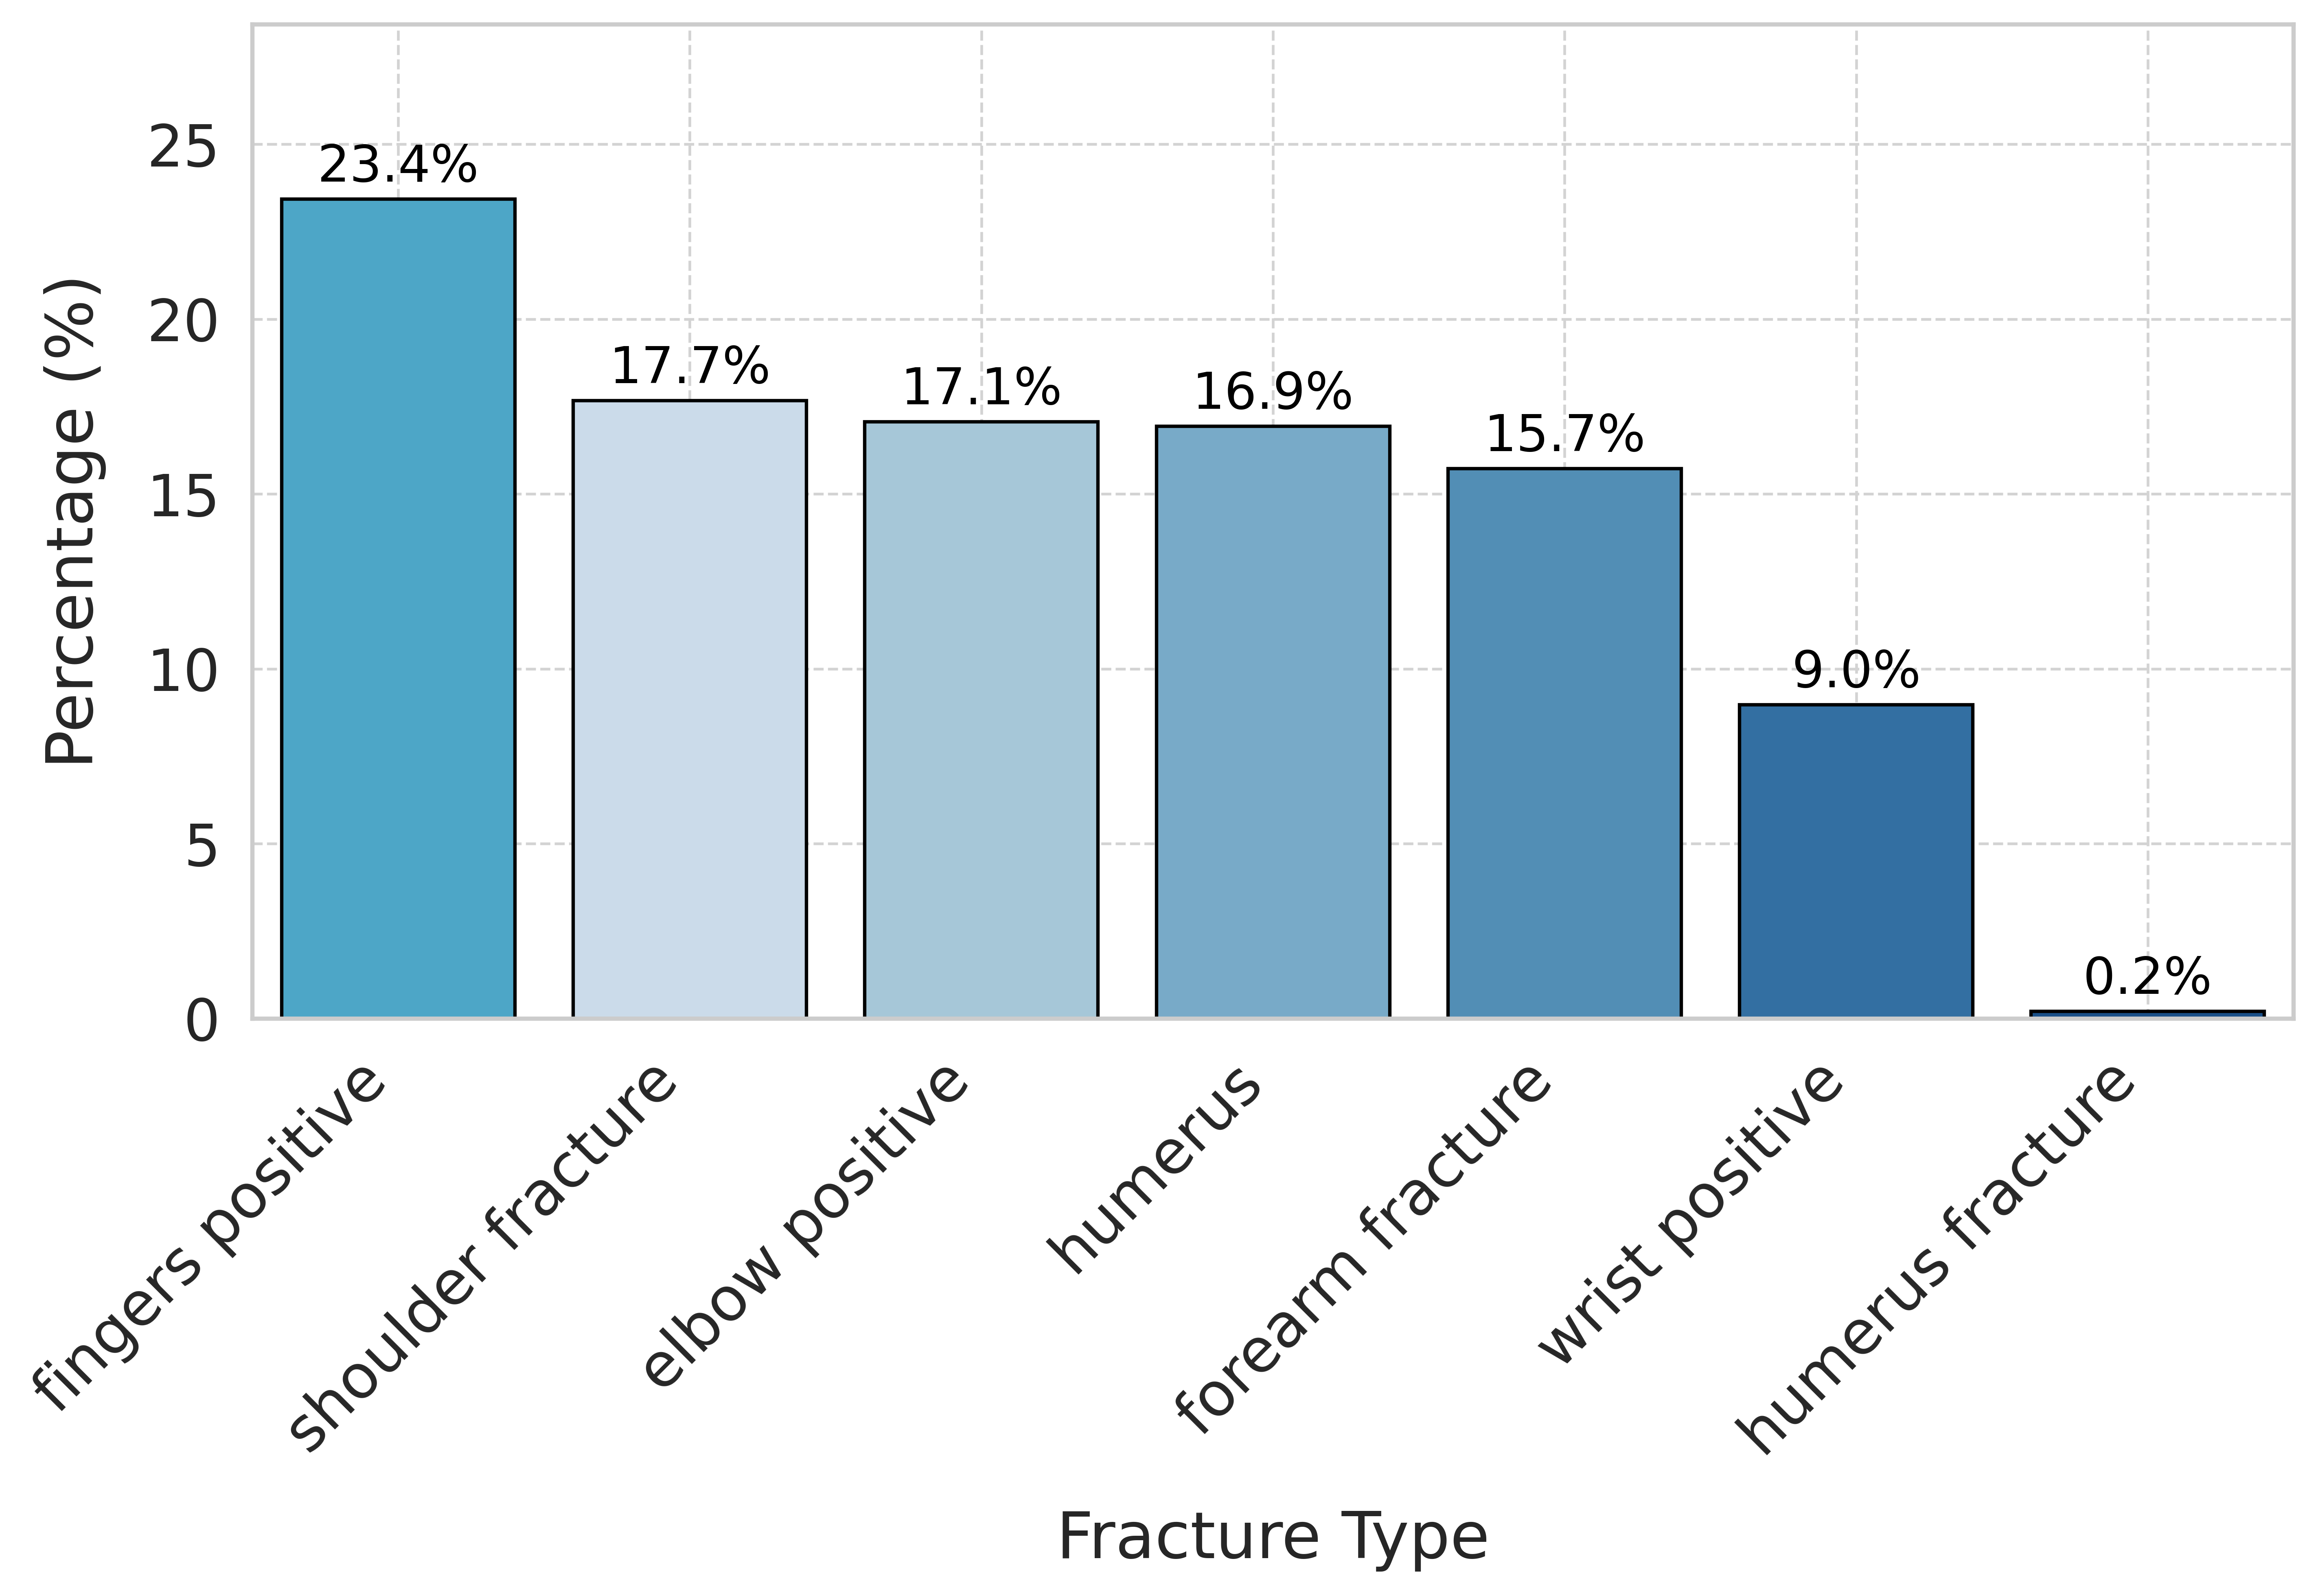

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==================== Load CSV ====================
metadata_csv = "/content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/metadata.csv"
df = pd.read_csv(metadata_csv)

# ==================== Data preparation ====================
df_unique = df.drop_duplicates(subset=["image_name", "class_id"])
class_counts = df_unique["class_name"].value_counts()
class_percent = (class_counts / class_counts.sum()) * 100

# ==================== Style & Colors ====================
sns.set(style="whitegrid")
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Original Seaborn palette (Blues)
pro_blue = sns.color_palette("Blues", n_colors=len(class_percent))

# ==================== Create the bar plot ====================
plt.figure(figsize=(10, 7), dpi=600)
ax = sns.barplot(
    x=class_percent.index,
    y=class_percent.values,
    palette=pro_blue
)

# ==================== Change color only for "fingers positive" ====================
for i, cls in enumerate(class_percent.index):
    if cls.lower() == "fingers positive":
        ax.patches[i].set_facecolor("#4DA6C7")  # rouge vif pour "fingers positive"

# Add borders to bars
for bar in ax.patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1)

# ==================== Customize appearance ====================
ax.set_ylabel("Percentage (%)", fontsize=19, labelpad=12)
ax.set_xlabel("Fracture Type", fontsize=19, labelpad=12)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=17)
ax.set_ylim(0, class_percent.max() + 5)

# Grid
ax.grid(True, which='both', axis='both', linestyle='--', color='lightgray', linewidth=0.8)
ax.set_axisbelow(True)

# Add percentage labels
for i, v in enumerate(class_percent.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=15, color="black")


# Save figure
plt.tight_layout(pad=2.0)
plt.savefig(
    "/content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/Distribution_of_fracture_types_fingers_highlight.pdf",
    format='pdf',
    bbox_inches='tight'
)
plt.show()


In [ ]:


# --- Chemin vers le CSV initial ---
metadata_path = "/content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/metadata.csv"

# Charger le CSV
df = pd.read_csv(metadata_path)

# --- Nettoyage des coordonnées ---
df['x_values'] = df['x_values'].astype(str)
df['y_values'] = df['y_values'].astype(str)

def str_to_float_list(coord_str):
    """Convertir une chaîne de coordonnées en liste de float"""
    try:
        return [float(x) for x in coord_str.split() if x.strip() != ""]
    except:
        return []

# Moyenne X et Y
df['x_list'] = df['x_values'].apply(str_to_float_list)
df['y_list'] = df['y_values'].apply(str_to_float_list)
df['x_moy'] = df['x_list'].apply(lambda l: np.mean(l) if l else np.nan)
df['y_moy'] = df['y_list'].apply(lambda l: np.mean(l) if l else np.nan)

# Estimation de la surface (bounding box approximative)
def bbox_area(x_list, y_list):
    if len(x_list) == 0 or len(y_list) == 0:
        return 0
    x_min, x_max = min(x_list), max(x_list)
    y_min, y_max = min(y_list), max(y_list)
    return (x_max - x_min) * (y_max - y_min)

df['area'] = df.apply(lambda row: bbox_area(row['x_list'], row['y_list']), axis=1)

# --- Agrégation par image ---
agg_df = df.groupby('image_name').agg(
    nb_fractures=('class_id', 'count'),
    classes_detectées=('class_name', lambda x: ', '.join(sorted(set(x)))),
    x_moyenne=('x_moy', 'mean'),
    y_moyenne=('y_moy', 'mean'),
    surface_moyenne=('area', 'mean')
).reset_index()

# Catégorie simple selon le nombre de fractures
agg_df['gravité'] = agg_df['nb_fractures'].apply(lambda x: 'légère' if x == 1 else 'multiple')

# --- Sauvegarde du CSV résumé ---
final_csv = os.path.join(os.path.dirname(metadata_path), "metadata_summary.csv")
agg_df.to_csv(final_csv, index=False, encoding='utf-8')

print(f"Métadonnées agrégées créées : {final_csv}")
print(f"Nombre d'images uniques résumées : {len(agg_df)}")




Métadonnées agrégées créées : /content/drive/MyDrive/thesis doc/bone fracture/bone fracture detection.v4-v4.yolov8/selected_data/metadata_summary.csv
Nombre d'images uniques résumées : 1491
